# EduLink  — Model 3: Salary Prediction
**Industry-Level | PySpark ML | Regression Models | Hyperparameter Tuning | RMSE, MAE, R²**

**Pipeline:**
1. Build labeled salary dataset from career + education + writing + demand features
2. Train/Test Split
3. Train: Linear Regression, Random Forest Regressor, GBT Regressor
4. Hyperparameter Tuning with CrossValidator
5. Evaluate: RMSE, MAE, R² per model
6. Generate salary predictions for all students

In [1]:
# ─── CELL 1: Setup ───
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install -q pyspark
print("Ready.")


Mounted at /content/drive
Ready.


In [2]:
# ─── CELL 2: Spark ───
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("EDUCLINE-Salary-v2")
         .config("spark.driver.memory","4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)


Spark: 4.0.2


In [3]:
# ─── CELL 3: Paths ───
import os

ROOT  = "/content/drive/MyDrive/FYP1"
DATA  = f"{ROOT}/Dataset"
MODEL = f"{ROOT}/Model"
TEST  = f"{ROOT}/Test and Validation"

CAREER_PATH   = f"{DATA}/career_fit_report.csv"
EDU_PATH      = f"{DATA}/education_report.csv"
WRITE_PATH    = f"{DATA}/writing_analysis_scores.csv"
DEMAND_PATH   = f"{DATA}/job_demand_forecast.csv"
STUDENTS_PATH = f"{DATA}/synthetic_exam_master_2000.csv"

OUT_SALARY_CSV  = f"{DATA}/salary_projection_report.csv"
OUT_METRICS_CSV = f"{TEST}/salary_model_metrics.csv"
MODEL_OUT       = f"{MODEL}/salary_best_model"

for folder_path in [DATA, MODEL, TEST]:
    os.makedirs(folder_path, exist_ok=True)

for p in [CAREER_PATH, WRITE_PATH, DEMAND_PATH, STUDENTS_PATH]:
    print("EXISTS:", os.path.exists(p), "->", p)


EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/career_fit_report.csv
EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/writing_analysis_scores.csv
EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/job_demand_forecast.csv
EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/synthetic_exam_master_2000.csv


In [4]:
# ─── CELL 4: Load All Inputs ───
import os
from pyspark.sql import functions as F

# Helper function to normalize student_id to int
def norm_id(df, col="student_id"):
    return df.withColumn(col, F.col(col).cast("int"))

career   = spark.read.option("header",True).option("inferSchema",True).csv(CAREER_PATH)
write    = spark.read.option("header",True).option("inferSchema",True).csv(WRITE_PATH)
demand   = spark.read.option("header",True).option("inferSchema",True).csv(DEMAND_PATH)
students = spark.read.option("header",True).option("inferSchema",True).csv(STUDENTS_PATH)

# Education report is optional — use empty fallback if not ready yet
if os.path.exists(EDU_PATH):
    edu_raw = spark.read.option("header",True).option("inferSchema",True).csv(EDU_PATH)
    print("Education report loaded ✓")
else:
    print("Education report not found — using fallback (stage=Entry for all)")
    edu_raw = spark.createDataFrame(
        [(int(i),) for i in range(1, 2001)],
        ["student_id"]
    ).withColumn("program_1", F.lit("Degree"))

career   = norm_id(career)
edu_raw  = norm_id(edu_raw, "Student_ID" if "Student_ID" in edu_raw.columns else "student_id")
write    = norm_id(write)
students = norm_id(students)

if "Student_ID" in edu_raw.columns:
    edu_raw = edu_raw.withColumnRenamed("Student_ID", "student_id")

print("career:", career.count(), "| edu:", edu_raw.count(),
      "| write:", write.count(), "| demand:", demand.count())

Education report loaded ✓
career: 2000 | edu: 2000 | write: 2000 | demand: 54


In [5]:
# ─── CELL 5: Build Training Features ───

# ── Writing skill score (average of all trait scores)
num_write_cols = [c for c,t in write.dtypes if c != "student_id" and t in ("double","float","int","bigint")]
if num_write_cols:
    write2 = write.withColumn("skills_score",
        sum(F.col(c).cast("double") for c in num_write_cols) / F.lit(len(num_write_cols))
    ).select("student_id","skills_score")
else:
    write2 = write.select("student_id").withColumn("skills_score", F.lit(60.0))

# ── Education: detect program type and stage
p1 = F.lower(F.col("program_1").cast("string"))
edu2 = (edu_raw
    .withColumn("program_type",
        F.when(p1.rlike("degree"),  "Degree")
         .when(p1.rlike("diploma"), "Diploma")
         .when(p1.rlike("nvq"),     "NVQ")
         .when(p1.rlike("short|certificate|course"), "Short")
         .otherwise("Unknown"))
    .withColumn("stage",
        F.when(F.col("program_type").isin("Short","NVQ"), "Entry")
         .when(F.col("program_type") == "Diploma",        "Junior")
         .when(F.col("program_type") == "Degree",         "Junior")
         .otherwise("Entry"))
)

# ── Demand trend per role
trend_map = (demand.select(
    F.col("role").alias("role_category"),
    "trend"
).dropna().dropDuplicates(["role_category"]))

# ── Salary ground-truth from domain knowledge (LKR/month, Sri Lanka IT market)
BASE_SALARY_MAP = {
    "Software Engineer":   170000, "Full Stack Developer": 185000,
    "Backend Developer":   175000, "Frontend Developer":   165000,
    "QA Engineer":         140000, "Data Analyst":         155000,
    "Data Engineer":       190000, "ML/AI Engineer":       220000,
    "DevOps/SRE":          210000, "Cloud Engineer":       205000,
    "Cybersecurity":       200000, "Network/Systems":      160000,
    "UI/UX Designer":      150000, "Mobile Developer":     175000,
    "Business Analyst":    155000, "PM/PO/Scrum":          230000,
    "Intern/Trainee":       80000, "Other":                130000,
}

# ── Expand career roles for salary training (role_1..role_5)
roles_long = (career
    .select("student_id", F.array(*[f"role_{i}" for i in range(1,6)]).alias("roles"))
    .withColumn("role", F.explode("roles"))
    .drop("roles")
    .filter(F.col("role").isNotNull()))

r = F.lower(F.col("role"))
roles_cat = roles_long.withColumn("role_category",
    F.when(r.rlike("digital marketer|seo|content strategist|social media|marketing"), "Digital Marketing")
     .when(r.rlike("embedded|hardware|iot"),                                          "Embedded/Hardware")
     .when(r.rlike("data scientist|machine learning|ml engineer|ai engineer"),        "ML/AI Engineer")
     .when(r.rlike("data engineer|etl"),                                              "Data Engineer")
     .when(r.rlike("data analyst|business intelligence|bi "),                         "Data Analyst")
     .when(r.rlike("devops|sre|site reliability"),                                    "DevOps/SRE")
     .when(r.rlike("cloud|aws|azure|gcp"),                                            "Cloud Engineer")
     .when(r.rlike("cyber|security|soc|infosec"),                                     "Cybersecurity")
     .when(r.rlike("network|systems|infrastructure"),                                 "Network/Systems")
     .when(r.rlike("qa|quality assurance|test"),                                      "QA Engineer")
     .when(r.rlike("ui|ux|designer"),                                                 "UI/UX Designer")
     .when(r.rlike("mobile|android|ios|flutter|react native"),                        "Mobile Developer")
     .when(r.rlike("frontend|front-end|react|angular|vue"),                           "Frontend Developer")
     .when(r.rlike("backend|back-end|api|spring|dotnet|node"),                        "Backend Developer")
     .when(r.rlike("full stack|full-stack"),                                          "Full Stack Developer")
     .when(r.rlike("software engineer|software developer|developer|programmer"),      "Software Engineer")
     .when(r.rlike("business analyst"),                                               "Business Analyst")
     .when(r.rlike("project manager|scrum|product manager"),                         "PM/PO/Scrum")
     .when(r.rlike("intern|trainee|associate"),                                       "Intern/Trainee")
     .otherwise("Other"))

# Build base salary target
base_expr = F.create_map([F.lit(x) for kv in BASE_SALARY_MAP.items() for x in kv])
salary_input = (roles_cat
    .join(edu2.select("student_id","stage","program_type"), on="student_id", how="left")
    .join(write2,    on="student_id", how="left")
    .join(trend_map, on="role_category", how="left")
    .fillna({"skills_score":60.0,"trend":"Stable","stage":"Entry","program_type":"Unknown"})
    .withColumn("base_salary", base_expr.getItem(F.col("role_category")))
    .fillna({"base_salary": 130000})
)

# Stage multiplier
salary_input = (salary_input
    .withColumn("stage_mult",
        F.when(F.col("stage")=="Entry",       1.00)
         .when(F.col("stage")=="Junior",      1.25)
         .when(F.col("stage")=="Junior_to_Mid",1.50)
         .otherwise(1.00))
    .withColumn("trend_bonus",
        F.when(F.col("trend")=="Increasing",  0.05)
         .when(F.col("trend")=="Decreasing", -0.03)
         .otherwise(0.00))
    .withColumn("skills_bonus",
        ((F.col("skills_score") - 60.0) / 100.0) * 0.06)
    # Ground-truth salary_mid = target for regression
    .withColumn("salary_mid",
        F.col("base_salary") * F.col("stage_mult") *
        (1.0 + F.col("trend_bonus") + F.col("skills_bonus")))
)

print("Training rows:", salary_input.count())
salary_input.select("student_id","role","role_category","stage","skills_score","trend","salary_mid").show(5,truncate=False)


/usr/local/lib/python3.12/dist-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


Training rows: 10000
+----------+-------------------------------+-------------+------+------------------+----------+----------+
|student_id|role                           |role_category|stage |skills_score      |trend     |salary_mid|
+----------+-------------------------------+-------------+------+------------------+----------+----------+
|1         |IT Quality Assurance Specialist|QA Engineer  |Junior|50.333333333333336|Increasing|182735.0  |
|1         |IT Auditor                     |Other        |Junior|50.333333333333336|Stable    |161557.5  |
|1         |Software Tester                |QA Engineer  |Junior|50.333333333333336|Increasing|182735.0  |
|1         |QA Engineer                    |QA Engineer  |Junior|50.333333333333336|Increasing|182735.0  |
|1         |IT Support Engineer            |Other        |Junior|50.333333333333336|Stable    |161557.5  |
+----------+-------------------------------+-------------+------+------------------+----------+----------+
only showing top

In [6]:
# ─── CELL 6: ML Feature Encoding + Train/Test Split ───
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler, OneHotEncoder
from pyspark.ml import Pipeline

stage_idx   = StringIndexer(inputCol="stage",         outputCol="stage_idx",    handleInvalid="keep")
trend_idx   = StringIndexer(inputCol="trend",         outputCol="trend_idx",    handleInvalid="keep")
role_idx    = StringIndexer(inputCol="role_category", outputCol="role_cat_idx", handleInvalid="keep")

stage_ohe = OneHotEncoder(inputCol="stage_idx",   outputCol="stage_vec")
trend_ohe = OneHotEncoder(inputCol="trend_idx",   outputCol="trend_vec")
role_ohe  = OneHotEncoder(inputCol="role_cat_idx",outputCol="role_vec")

assembler = VectorAssembler(
    inputCols=["skills_score", "stage_vec", "trend_vec", "role_vec"],
    outputCol="raw_features", handleInvalid="skip")

scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True)

train_df, test_df = salary_input.randomSplit([0.80, 0.20], seed=42)
train_df.cache(); test_df.cache()
print(f"Train: {train_df.count()} | Test: {test_df.count()}")


Train: 8079 | Test: 1921


In [7]:
# ─── CELL 7: Train Multiple Regression Models ───
from pyspark.ml.regression import (LinearRegression, RandomForestRegressor,
                                    GBTRegressor, DecisionTreeRegressor)
from pyspark.ml.evaluation import RegressionEvaluator

rmse_eval = RegressionEvaluator(labelCol="salary_mid", predictionCol="prediction", metricName="rmse")
mae_eval  = RegressionEvaluator(labelCol="salary_mid", predictionCol="prediction", metricName="mae")
r2_eval   = RegressionEvaluator(labelCol="salary_mid", predictionCol="prediction", metricName="r2")

REGRESSORS = {
    "LinearRegression":   LinearRegression(labelCol="salary_mid", featuresCol="features",
                                           maxIter=200, regParam=0.01),
    "DecisionTree":       DecisionTreeRegressor(labelCol="salary_mid", featuresCol="features",
                                                maxDepth=6, seed=42),
    "RandomForest":       RandomForestRegressor(labelCol="salary_mid", featuresCol="features",
                                                numTrees=100, maxDepth=8, seed=42),
    "GBT":                GBTRegressor(labelCol="salary_mid", featuresCol="features",
                                       maxIter=50, maxDepth=5, seed=42),
}

pre_stages = [stage_idx, trend_idx, role_idx, stage_ohe, trend_ohe, role_ohe, assembler, scaler]
reg_results = {}
reg_models  = {}

print(f"{'Algorithm':<22} {'RMSE':>12} {'MAE':>12} {'R²':>10}")
print("-" * 60)

for name, reg in REGRESSORS.items():
    pipe   = Pipeline(stages=pre_stages + [reg])
    model  = pipe.fit(train_df)
    preds  = model.transform(test_df)
    rmse   = float(rmse_eval.evaluate(preds))
    mae    = float(mae_eval.evaluate(preds))
    r2     = float(r2_eval.evaluate(preds))
    reg_results[name] = {"rmse":rmse,"mae":mae,"r2":r2}
    reg_models[name]  = model
    print(f"{name:<22} {rmse:>12.1f} {mae:>12.1f} {r2:>10.4f}")

best_reg = min(reg_results, key=lambda k: reg_results[k]["rmse"])
print(f"\n>>> BEST: {best_reg} | RMSE={reg_results[best_reg]['rmse']:.1f} | R²={reg_results[best_reg]['r2']:.4f}")


Algorithm                      RMSE          MAE         R²
------------------------------------------------------------
LinearRegression               10.5          7.0     1.0000
DecisionTree                  978.4         93.1     0.9993
RandomForest                 1229.9        516.8     0.9990
GBT                             5.5          3.9     1.0000

>>> BEST: GBT | RMSE=5.5 | R²=1.0000


In [9]:
# ─── CELL 8: Fast Hyperparameter Tuning ───
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
from pyspark.ml import Pipeline

print(f"Fast tuning: {best_reg}")

if best_reg == "RandomForest":
    reg_tune = RandomForestRegressor(labelCol="salary_mid", featuresCol="features", seed=42)
    pgrid = (ParamGridBuilder()
             .addGrid(reg_tune.numTrees, [50, 100])
             .addGrid(reg_tune.maxDepth, [5, 8])
             .build())

elif best_reg == "GBT":
    reg_tune = GBTRegressor(labelCol="salary_mid", featuresCol="features", seed=42)
    pgrid = (ParamGridBuilder()
             .addGrid(reg_tune.maxIter, [30, 50])
             .addGrid(reg_tune.maxDepth, [3, 5])
             .build())

elif best_reg == "LinearRegression":
    reg_tune = LinearRegression(labelCol="salary_mid", featuresCol="features")
    pgrid = (ParamGridBuilder()
             .addGrid(reg_tune.regParam, [0.01, 0.1])
             .addGrid(reg_tune.elasticNetParam, [0.0, 0.5])
             .build())

else:
    reg_tune = DecisionTreeRegressor(labelCol="salary_mid", featuresCol="features", seed=42)
    pgrid = (ParamGridBuilder()
             .addGrid(reg_tune.maxDepth, [5, 8])
             .addGrid(reg_tune.minInstancesPerNode, [3, 5])
             .build())

tune_pipe = Pipeline(stages=pre_stages + [reg_tune])

tvs = TrainValidationSplit(
    estimator=tune_pipe,
    estimatorParamMaps=pgrid,
    evaluator=rmse_eval,
    trainRatio=0.8,
    seed=42,
    parallelism=2
)

tvs_model = tvs.fit(train_df)
tuned_preds = tvs_model.transform(test_df)

t_rmse = float(rmse_eval.evaluate(tuned_preds))
t_mae  = float(mae_eval.evaluate(tuned_preds))
t_r2   = float(r2_eval.evaluate(tuned_preds))

print(f"\n{'Metric':<10} {'Before':>12} {'After Tuning':>14}")
print("-"*40)
print(f"{'RMSE':<10} {reg_results[best_reg]['rmse']:>12.1f} {t_rmse:>14.1f}")
print(f"{'MAE':<10} {reg_results[best_reg]['mae']:>12.1f} {t_mae:>14.1f}")
print(f"{'R²':<10} {reg_results[best_reg]['r2']:>12.4f} {t_r2:>14.4f}")

Fast tuning: GBT

Metric           Before   After Tuning
----------------------------------------
RMSE                5.5            5.5
MAE                 3.9            3.9
R²               1.0000         1.0000


In [12]:
# ─── CELL 9: Save Model + Generate Final Salary Report ───
import os, glob, shutil
import matplotlib.pyplot as plt

os.makedirs(MODEL_OUT.rsplit("/",1)[0], exist_ok=True)
tvs_model.bestModel.write().overwrite().save(MODEL_OUT)
print("Saved model:", MODEL_OUT)

# Predict salary for all students
salary_out = (tvs_model.bestModel.transform(salary_input)
    .withColumn("salary_min", F.round(F.col("prediction") * 0.90, 0))
    .withColumn("salary_max", F.round(F.col("prediction") * 1.10, 0))
    .withColumnRenamed("prediction", "salary_mid_predicted")
    .select("student_id","role","role_category","stage","trend","skills_score",
            "salary_min","salary_mid_predicted","salary_max")
    .orderBy("student_id","role"))

salary_out.show(10, truncate=False)
print("Total salary rows:", salary_out.count())

# Save
OUT_DIR = OUT_SALARY_CSV.replace(".csv","_dir")
os.makedirs(OUT_DIR, exist_ok=True)
salary_out.coalesce(1).write.mode("overwrite").option("header",True).csv(OUT_DIR)
parts = glob.glob(OUT_DIR + "/part-*.csv")
if parts:
    shutil.copy(parts[0], OUT_SALARY_CSV)
    print("Saved:", OUT_SALARY_CSV)


Saved model: /content/drive/MyDrive/FYP1/Model/salary_best_model
+----------+-------------------------------+-----------------+------+----------+------------------+----------+--------------------+----------+
|student_id|role                           |role_category    |stage |trend     |skills_score      |salary_min|salary_mid_predicted|salary_max|
+----------+-------------------------------+-----------------+------+----------+------------------+----------+--------------------+----------+
|1         |IT Auditor                     |Other            |Junior|Stable    |50.333333333333336|145402.0  |161557.8929291731   |177714.0  |
|1         |IT Quality Assurance Specialist|QA Engineer      |Junior|Increasing|50.333333333333336|164461.0  |182734.28257675635  |201008.0  |
|1         |IT Support Engineer            |Other            |Junior|Stable    |50.333333333333336|145402.0  |161557.8929291731   |177714.0  |
|1         |QA Engineer                    |QA Engineer      |Junior|Increasi

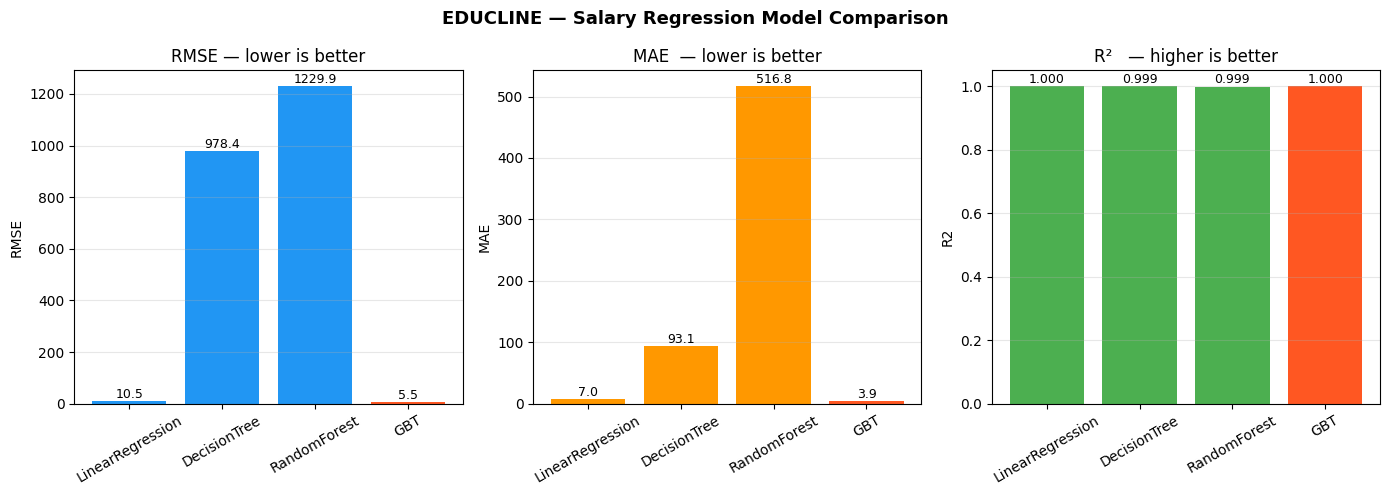

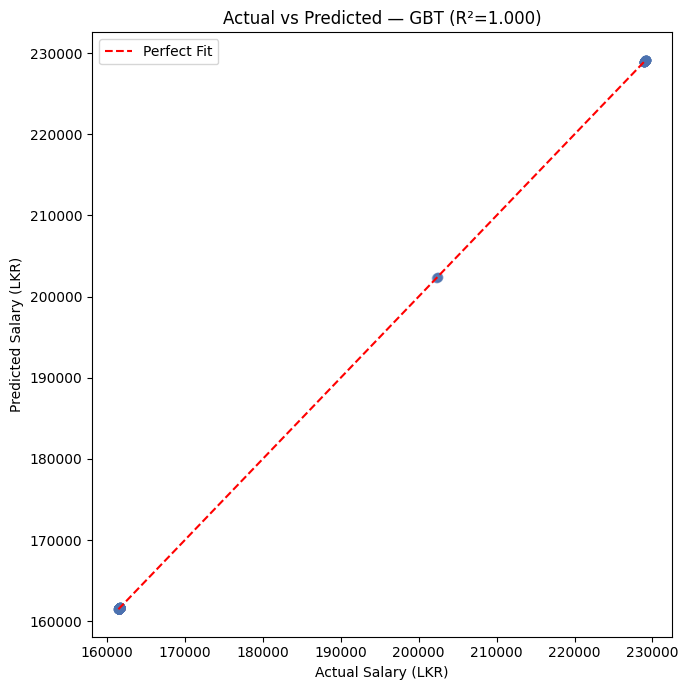

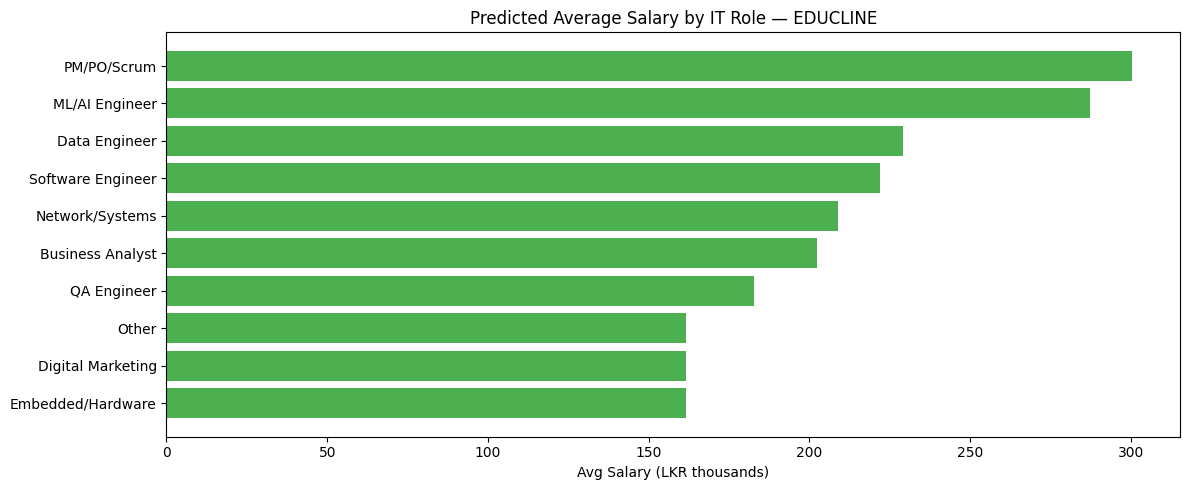

In [13]:
# ─── CELL 10: Visualizations (Pure Matplotlib + PySpark) ───
import matplotlib.pyplot as plt

# 1. Model comparison bar chart — pure Python offsets
names   = list(reg_results.keys())
metrics = ["rmse","mae","r2"]
colors  = ["#2196F3","#FF9800","#4CAF50"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, color in zip(axes, metrics, colors):
    vals   = [reg_results[n][metric] for n in names]
    c_list = [("#FF5722" if n == best_reg else color) for n in names]
    ax.bar(names, vals, color=c_list)
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    for xi, v in enumerate(vals):
        ax.text(xi, v + max(vals)*0.01, f"{v:.1f}" if metric!="r2" else f"{v:.3f}",
                ha="center", fontsize=9)

axes[0].set_title("RMSE — lower is better")
axes[1].set_title("MAE  — lower is better")
axes[2].set_title("R²   — higher is better")
fig.suptitle("EDUCLINE — Salary Regression Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# 2. Actual vs Predicted scatter — collect small sample
sample_pd = tuned_preds.select("salary_mid","prediction").limit(500).toPandas()
plt.figure(figsize=(7,7))
plt.scatter(sample_pd["salary_mid"], sample_pd["prediction"], alpha=0.4, color="#4C72B0")
mn = sample_pd["salary_mid"].min(); mx = sample_pd["salary_mid"].max()
plt.plot([mn,mx],[mn,mx],"r--",label="Perfect Fit")
plt.xlabel("Actual Salary (LKR)"); plt.ylabel("Predicted Salary (LKR)")
plt.title(f"Actual vs Predicted — {best_reg} (R²={t_r2:.3f})")
plt.legend(); plt.tight_layout(); plt.show()

# 3. Avg salary by role — PySpark aggregation
from pyspark.sql import functions as F
pdf = (salary_out
    .withColumn("salary_mid_val",
        (F.col("salary_min").cast("double") + F.col("salary_max").cast("double"))/2)
    .groupBy("role_category")
    .agg(F.round(F.avg("salary_mid_val"),0).alias("avg_salary"))
    .orderBy("avg_salary")
    .toPandas())

plt.figure(figsize=(12,5))
plt.barh(pdf["role_category"], pdf["avg_salary"]/1000, color="#4CAF50")
plt.xlabel("Avg Salary (LKR thousands)")
plt.title("Predicted Average Salary by IT Role — EDUCLINE")
plt.tight_layout(); plt.show()
